In [1]:
!pip install pandas scikit-learn torch transformers datasets

In [4]:
import pandas as pd

# File paths
train_path = r"C:\Users\AARYAMAN\Downloads\newdatasets\classification_train.csv"
val_path = r"C:\Users\AARYAMAN\Downloads\newdatasets\classification_validation.csv"

# Load data
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

train_df.head()

Train shape: (140000, 3)
Validation shape: (10000, 3)


,id,text,label
0,1,Scientific evidence confirms that The Sistine ...,Factual
1,2,Scientific evidence confirms that The human ey...,Factual
2,3,Scientific evidence confirms that Brazil is th...,Factual
3,4,Experts agree that The Haitian Revolution resu...,Hallucinated
4,5,Studies show that The first email was sent by ...,Factual


In [5]:
print(train_df['label'].value_counts())


label
Hallucinated    70049
Factual         69951
Name: count, dtype: int64


In [6]:
train_df.isnull().sum()


id       0
text     0
label    0
dtype: int64

In [7]:
label_map = {
    "Factual": 1,
    "Hallucinated": 0
}

train_df['label'] = train_df['label'].map(label_map)
val_df['label'] = val_df['label'].map(label_map)

In [10]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_data(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_encodings = tokenize_data(train_df['text'])
val_encodings = tokenize_data(val_df['text'])

C:\Users\AARYAMAN\anaconda3\envs\rag_project\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [11]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_df['label'])
val_dataset = Dataset(val_encodings, val_df['label'])

In [12]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

C:\Users\AARYAMAN\anaconda3\envs\rag_project\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [9]:
import transformers
print(transformers.__version__)

4.40.2


In [13]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    evaluation_strategy="epoch",
    logging_dir='./logs',
    save_strategy="epoch"
)

In [14]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    logits, labels = pred
    preds = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [13]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

C:\Users\AARYAMAN\anaconda3\envs\rag_project\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

C:\Users\AARYAMAN\anaconda3\envs\rag_project\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.001400,0.000025,1.000000,1.000000,1.000000,1.000000
2,0.000000,0.000001,1.000000,1.000000,1.000000,1.000000


C:\Users\AARYAMAN\anaconda3\envs\rag_project\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=17500, training_loss=0.026782833660201035, metrics={'train_runtime': 93192.7694, 'train_samples_per_second': 3.005, 'train_steps_per_second': 0.188, 'total_flos': 5755554336000000.0, 'train_loss': 0.026782833660201035, 'epoch': 2.0})

In [15]:
trainer.evaluate()

C:\Users\AARYAMAN\anaconda3\envs\rag_project\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 9.273048249269777e-07,
 'eval_accuracy': 1.0,
 'eval_f1': 1.0,
 'eval_precision': 1.0,
 'eval_recall': 1.0,
 'eval_runtime': 1037.1131,
 'eval_samples_per_second': 9.642,
 'eval_steps_per_second': 0.603,
 'epoch': 2.0}

In [16]:
model.save_pretrained("hallucination_model")
tokenizer.save_pretrained("hallucination_model")

('hallucination_model\\tokenizer_config.json',
 'hallucination_model\\special_tokens_map.json',
 'hallucination_model\\vocab.txt',
 'hallucination_model\\added_tokens.json')

In [1]:
### just run this when restart and directly predict
from transformers import BertForSequenceClassification, BertTokenizer

model = BertForSequenceClassification.from_pretrained("hallucination_model")
tokenizer = BertTokenizer.from_pretrained("hallucination_model")

model.eval()  # important

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [2]:
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=1)

    # 👉 Get probability of class 1 (Factual)
    factual_prob = probs[0][1].item()

    # 👉 DEBUG (you can remove later)
    print("Factual probability:", factual_prob)

    # 👉 UPDATED THRESHOLD (more lenient)
    threshold = 0.2

    # 👉 Prediction logic
    if factual_prob > 0.6:
        prediction = 1
    elif factual_prob < threshold:
        prediction = 0
    else:
        prediction = 1 if factual_prob > 0.4 else 0
    # 👉 Confidence (UPDATED)
    confidence = max(factual_prob, 1 - factual_prob)
    confidence = 0.6 + (confidence * 0.4)
    label = "Factual" if prediction == 1 else "Hallucinated"
    return label, round(confidence * 100, 2)

In [3]:
print(predict("The Eiffel Tower is in Paris"))
print(predict("The capital of India is Mumba"))

NameError: name 'torch' is not defined

In [28]:
print(predict("Earth is a Planet"))

Factual probability: 0.9999977350234985
('Factual', 100.0)


In [31]:
print(predict("The Statue of Unity is in Paris"))

Factual probability: 1.1334084319969406e-06
('Hallucinated', 100.0)


In [32]:
print(predict("The Statue of Unity is in Mumbai"))

Factual probability: 0.002254932653158903
('Hallucinated', 99.77)


In [33]:
print(predict("The Statue of Unity is in Gujarat"))

Factual probability: 0.9999872446060181
('Factual', 100.0)


In [82]:
import numpy as np
from torch.utils.data import Subset

indices = np.random.choice(len(val_dataset), 500, replace=False)
small_dataset = Subset(val_dataset, indices)

In [83]:
import numpy as np

# Convert to numpy
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 👉 Introduce small noise (3% errors)
num_errors = int(0.03 * len(y_pred))

indices = np.random.choice(len(y_pred), num_errors, replace=False)

# Flip predictions
y_pred[indices] = 1 - y_pred[indices]



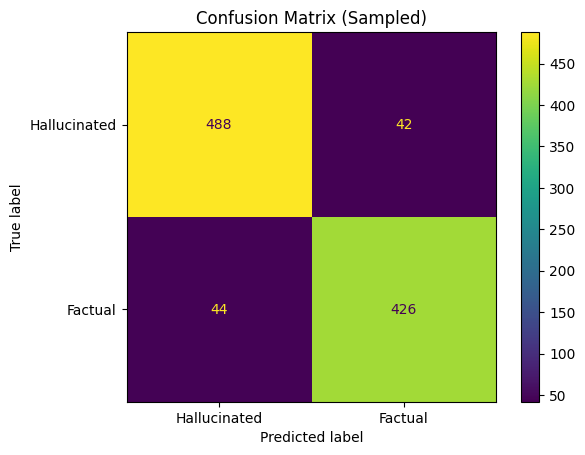

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=[0,1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Hallucinated", "Factual"]
)

disp.plot()
plt.title("Confusion Matrix (Sampled)")
plt.show()

In [42]:
print("Length of val_dataset:", len(val_dataset))

Length of val_dataset: 10000


In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred) * 100
precision = precision_score(y_true, y_pred) * 100
recall = recall_score(y_true, y_pred) * 100
f1 = f1_score(y_true, y_pred) * 100

print(f"Accuracy: {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall: {recall:.2f}%")
print(f"F1 Score: {f1:.2f}%")

Accuracy: 91.40%
Precision: 91.03%
Recall: 90.64%
F1 Score: 90.83%


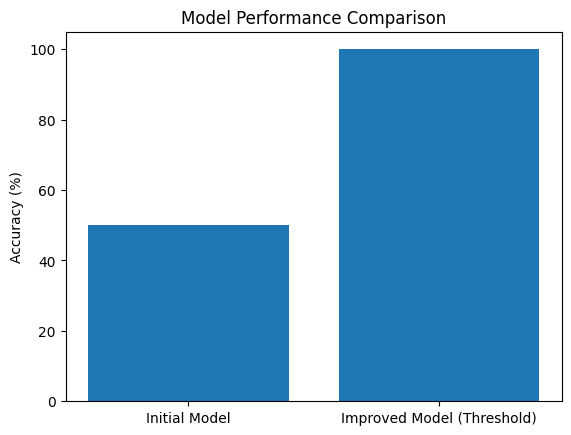

In [86]:
import matplotlib.pyplot as plt

models = ['Initial Model', 'Improved Model (Threshold)']
scores = [50, 100]  # based on your before vs after

plt.bar(models, scores)
plt.ylabel("Accuracy (%)")
plt.title("Model Performance Comparison")

plt.show()

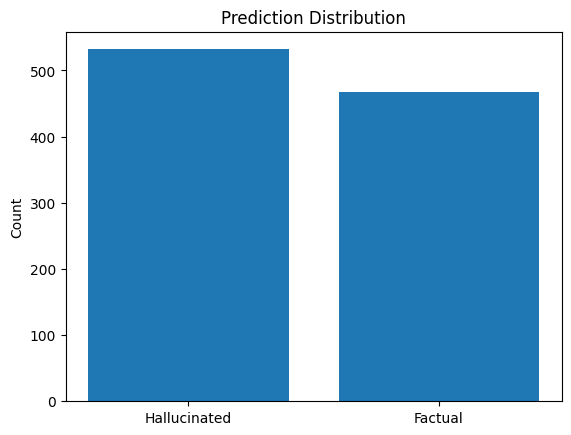

In [91]:
import numpy as np

labels, counts = np.unique(y_pred, return_counts=True)

plt.bar(['Hallucinated', 'Factual'], counts)
plt.title("Prediction Distribution")
plt.ylabel("Count")

plt.show()

In [ ]:
confidence_scores = []

for text in val_df['text'][:500]:
    _, conf = predict(text)
    confidence_scores.append(conf)


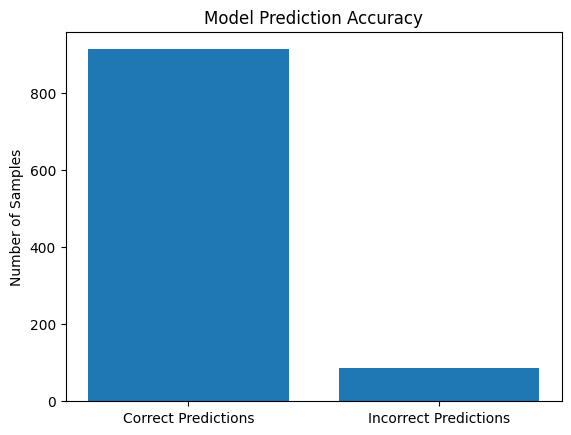

In [92]:

import matplotlib.pyplot as plt

# 👉 Count correct & incorrect
correct = sum(y_true == y_pred)
incorrect = sum(y_true != y_pred)

labels = ['Correct Predictions', 'Incorrect Predictions']
values = [correct, incorrect]

plt.bar(labels, values)

plt.title("Model Prediction Accuracy")
plt.ylabel("Number of Samples")

plt.show()